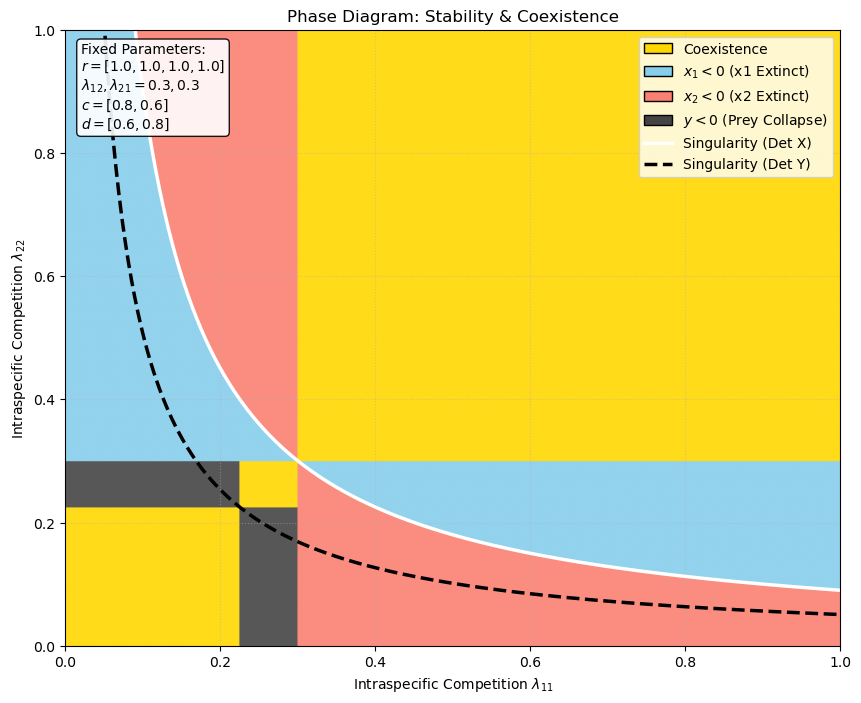

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. パラメータ設定
params = {
    'r': [1.0, 1.0, 1.0, 1.0],      # [rx1, ry1, rx2, ry2]
    'lambda_offdiag': [0.3, 0.3],   # [lambda12, lambda21] (定数)
    'c': [0.8, 0.6],                # [c1, c2]
    'd': [0.6, 0.8]                 # [d1, d2]
}

rx1, ry1, rx2, ry2 = params['r']
l12, l21 = params['lambda_offdiag']
c1, c2 = params['c']
d1, d2 = params['d']

# 2. メッシュグリッド
res = 400
vals = np.linspace(0.001, 1.0, res)
L11, L22 = np.meshgrid(vals, vals)

# 3. 計算
# L11, L22を変数、l12, l21を定数として計算
Det_x = L11 * L22 - l12 * l21
Det_y = c1 * d2 * L11 * L22 - c2 * d1 * l12 * l21

Num_x1 = L22 * ry1 - l12 * ry2
Num_x2 = L11 * ry2 - l21 * ry1
Num_y1 = d2 * L22 * rx1 - d1 * l21 * rx2
Num_y2 = c1 * L11 * rx2 - c2 * l12 * rx1

# 平衡点の値を計算 (ゼロ除算は無視)
with np.errstate(divide='ignore', invalid='ignore'):
    X1 = Num_x1 / Det_x
    X2 = Num_x2 / Det_x
    Y1 = Num_y1 / Det_y
    Y2 = Num_y2 / Det_y
# 4. 領域のカテゴリ分け
Category = np.zeros_like(X1, dtype=int)

pos_x1 = X1 > 0
pos_x2 = X2 > 0
pos_y1 = Y1 > 0
pos_y2 = Y2 > 0

mask_y_die = (~pos_y1) | (~pos_y2)
Category[mask_y_die] = 4
mask_x1_die = (~pos_x1) & pos_x2
Category[mask_x1_die] = 2
mask_x2_die = pos_x1 & (~pos_x2)
Category[mask_x2_die] = 3
mask_coexist = pos_x1 & pos_x2 & pos_y1 & pos_y2
Category[mask_coexist] = 1

# 5. プロット
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['white', 'gold', 'skyblue', 'salmon', '#444444']
cmap = ListedColormap(colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

im = ax.imshow(Category, extent=[0, 1.0, 0, 1.0], origin='lower',
               cmap=cmap, norm=norm, aspect='auto', alpha=0.9)

# --- 曲線描画 ---
x_line = np.linspace(0.001, 1.0, 500)
y_line1 = (l12 * l21) / x_line

numerator_curve = c2 * d1 * l12 * l21
denominator_curve = c1 * d2
y_line2 = numerator_curve / (denominator_curve * x_line)

ax.plot(x_line, y_line1, color='white', linestyle='-', linewidth=2.5, label=r'$\lambda_{11}\lambda_{22} = \lambda_{12}\lambda_{21}$')
ax.plot(x_line, y_line2, color='black', linestyle='--', linewidth=2.5, label=r'$C_1 d_2 \lambda_{11}\lambda_{22} = C_2 d_1 \lambda_{12}\lambda_{21}$')

# --- パラメータ表示 (修正箇所) ---
# ここで tuple() を使わず、単純な (c1, c2) のタプル形式を使用します
textstr = '\n'.join(( 
    r'Fixed Parameters:',
    r'$r = [%.1f, %.1f, %.1f, %.1f]$' % tuple(params['r']),
    r'$\lambda_{12}, \lambda_{21} = %.1f, %.1f$' % (l12, l21),
    r'$c = [%.1f, %.1f]$' % (c1, c2),
    r'$d = [%.1f, %.1f]$' % (d1, d2)
))

props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# 軸ラベルとタイトル
ax.set_ylim(0, 1.0)
ax.set_xlabel(r'Intraspecific Competition $\lambda_{11}$')
ax.set_ylabel(r'Intraspecific Competition $\lambda_{22}$')
ax.set_title('Phase Diagram: Stability & Coexistence')
ax.grid(True, linestyle=':', alpha=0.5)

legend_elements = [
    Patch(facecolor='gold', edgecolor='k', label='Coexistence'),
    Patch(facecolor='skyblue', edgecolor='k', label='$x_1 < 0$ (x1 Extinct)'),
    Patch(facecolor='salmon', edgecolor='k', label='$x_2 < 0$ (x2 Extinct)'),
    Patch(facecolor='#444444', edgecolor='k', label='$y < 0$ (Prey Collapse)'),
    Line2D([0], [0], color='white', lw=2.5, label=r'Singularity (Det X)'),
    Line2D([0], [0], color='black', lw=2.5, linestyle='--', label=r'Singularity (Det Y)')
]

ax.legend(handles=legend_elements, loc='upper right')

plt.show()

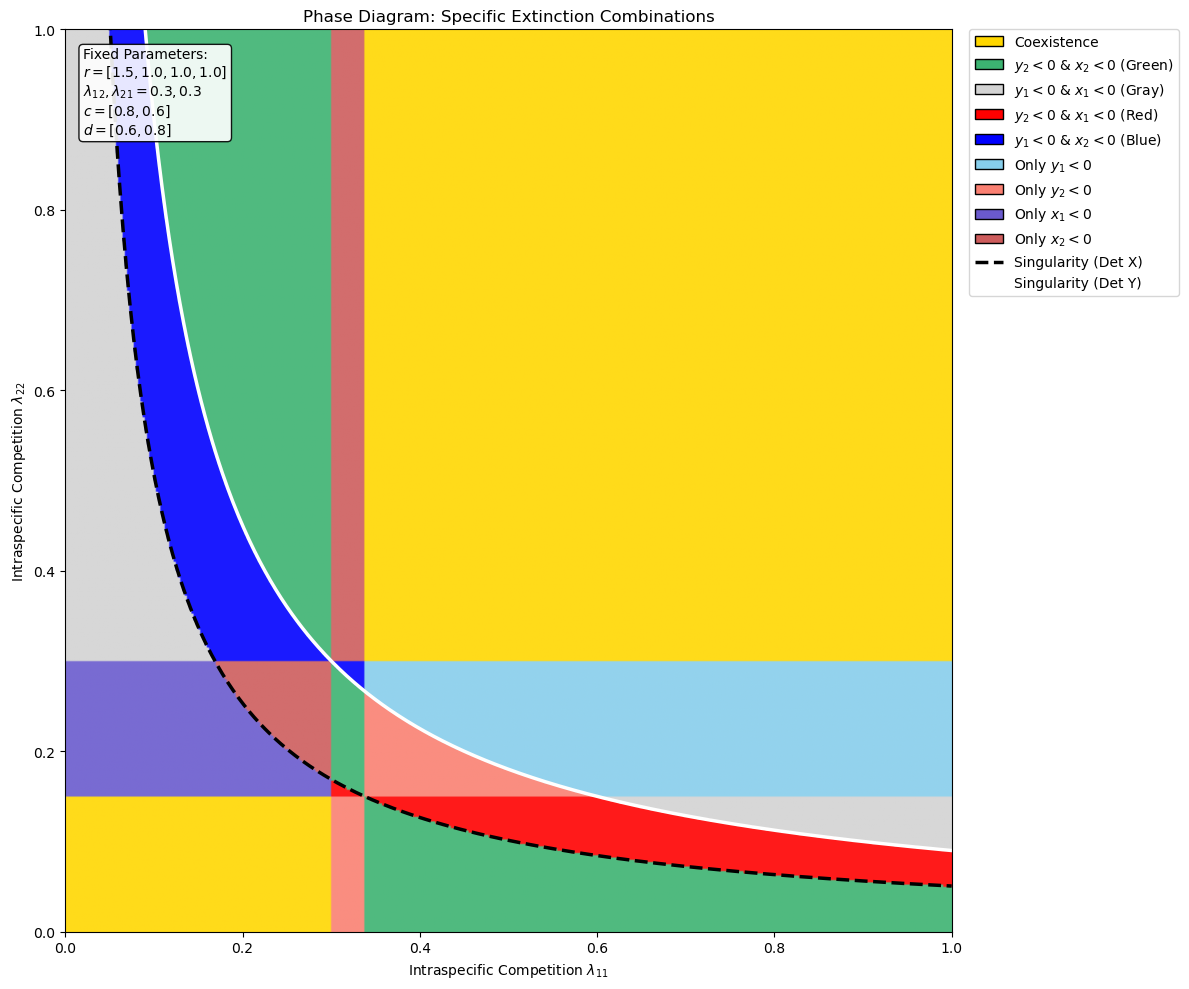

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. パラメータ設定
params = {
    'r': [1.5, 1.0, 1.0, 1.0],      # [rx1, ry1, rx2, ry2]
    'lambda_offdiag': [0.3, 0.3],   # [lambda12, lambda21]
    'c': [0.8, 0.6],                # [c1, c2]
    'd': [0.6, 0.8]                 # [d1, d2]
}

rx1, ry1, rx2, ry2 = params['r']
l12, l21 = params['lambda_offdiag']
c1, c2 = params['c']
d1, d2 = params['d']

# 2. メッシュグリッド
res = 400
vals = np.linspace(0.001, 1.0, res)
L11, L22 = np.meshgrid(vals, vals)

# 3. 計算 (x=被食者, y=捕食者 の構造)
Det_x = c1 * d2 * L11 * L22 - c2 * d1 * l12 * l21
Det_y = L11 * L22 - l12 * l21

Num_x1 = d2 * L22 * rx1 - d1 * l21 * rx2
Num_x2 = c1 * L11 * rx2 - c2 * l12 * rx1
Num_y1 = L22 * ry1 - l12 * ry2
Num_y2 = L11 * ry2 - l21 * ry1

with np.errstate(divide='ignore', invalid='ignore'):
    X1 = Num_x1 / Det_x
    X2 = Num_x2 / Det_x
    Y1 = Num_y1 / Det_y
    Y2 = Num_y2 / Det_y

# 4. 領域のカテゴリ分け (修正箇所: 条件マスクの追加)
Category = np.zeros_like(X1, dtype=int)

pos_x1 = X1 > 0
pos_x2 = X2 > 0
pos_y1 = Y1 > 0
pos_y2 = Y2 > 0

# --- Step 1: ベースとなる単独絶滅 (優先度: 低) ---
# これらは複合条件に上書きされる前提の「背景」として塗ります
Category[~pos_y1] = 2  # y1 < 0 (SkyBlue)
Category[~pos_y2] = 3  # y2 < 0 (Salmon)
Category[~pos_x1] = 4  # x1 < 0 (SlateBlue)
Category[~pos_x2] = 5  # x2 < 0 (IndianRed)

# --- Step 2: ご指定の複合条件 (優先度: 高) ---
# 上書きしていきます

# 緑: y2 < 0 && x2 < 0
mask_green = (~pos_y2) & (~pos_x2)
Category[mask_green] = 6

# 灰色: y1 < 0 && x1 < 0
mask_gray = (~pos_y1) & (~pos_x1)
Category[mask_gray] = 7

# 赤色: y2 < 0 && x1 < 0
mask_red = (~pos_y2) & (~pos_x1)
Category[mask_red] = 8

# 青色: y1 < 0 && x2 < 0
mask_blue = (~pos_y1) & (~pos_x2)
Category[mask_blue] = 9

# --- Step 3: 共存 (最優先) ---
mask_coexist = pos_x1 & pos_x2 & pos_y1 & pos_y2
Category[mask_coexist] = 1

# 5. プロット
fig, ax = plt.subplots(figsize=(12, 10)) # 凡例が増えたので少し大きくします

# カラーマップ定義 (0〜9)
colors = [
    'white',        # 0: None
    'gold',         # 1: Coexistence
    'skyblue',      # 2: y1 single extinction
    'salmon',       # 3: y2 single extinction
    'SlateBlue',    # 4: x1 single extinction
    'IndianRed',    # 5: x2 single extinction
    'MediumSeaGreen', # 6: y2<0 & x2<0 (Green)
    'lightgray',    # 7: y1<0 & x1<0 (Gray)
    'red',          # 8: y2<0 & x1<0 (Red)
    'blue'          # 9: y1<0 & x2<0 (Blue)
]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

im = ax.imshow(Category, extent=[0, 1.0, 0, 1.0], origin='lower',
               cmap=cmap, norm=norm, aspect='auto', alpha=0.9)

# --- 曲線描画 ---
x_line = np.linspace(0.001, 1.0, 500)
y_line1 = (l12 * l21) / x_line
numerator_curve = c2 * d1 * l12 * l21
denominator_curve = c1 * d2
y_line2 = numerator_curve / (denominator_curve * x_line)

ax.plot(x_line, y_line1, color='white', linestyle='-', linewidth=2.5, label=r'Singularity ($Det_y = 0$)')
ax.plot(x_line, y_line2, color='black', linestyle='--', linewidth=2.5, label=r'Singularity ($Det_x = 0$)')

# --- パラメータ表示 ---
textstr = '\n'.join((
    r'Fixed Parameters:',
    r'$r = [%.1f, %.1f, %.1f, %.1f]$' % tuple(params['r']),
    r'$\lambda_{12}, \lambda_{21} = %.1f, %.1f$' % (l12, l21),
    r'$c = [%.1f, %.1f]$' % (c1, c2),
    r'$d = [%.1f, %.1f]$' % (d1, d2)
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)

ax.set_ylim(0, 1.0)
ax.set_xlabel(r'Intraspecific Competition $\lambda_{11}$')
ax.set_ylabel(r'Intraspecific Competition $\lambda_{22}$')
ax.set_title('Phase Diagram: Specific Extinction Combinations')

# --- 凡例 (整理して表示) ---
legend_elements = [
    Patch(facecolor='gold', edgecolor='k', label='Coexistence'),
    
    # 指定の組み合わせ
    Patch(facecolor='MediumSeaGreen', edgecolor='k', label='$y_2 < 0$ & $x_2 < 0$ (Green)'),
    Patch(facecolor='lightgray', edgecolor='k', label='$y_1 < 0$ & $x_1 < 0$ (Gray)'),
    Patch(facecolor='red', edgecolor='k', label='$y_2 < 0$ & $x_1 < 0$ (Red)'),
    Patch(facecolor='blue', edgecolor='k', label='$y_1 < 0$ & $x_2 < 0$ (Blue)'),
    
    # 単独・その他
    Patch(facecolor='skyblue', edgecolor='k', label='Only $y_1 < 0$'),
    Patch(facecolor='salmon', edgecolor='k', label='Only $y_2 < 0$'),
    Patch(facecolor='SlateBlue', edgecolor='k', label='Only $x_1 < 0$'),
    Patch(facecolor='IndianRed', edgecolor='k', label='Only $x_2 < 0$'),
    
    Line2D([0], [0], color='black', lw=2.5, linestyle='--', label=r'Singularity (Det X)'),
    Line2D([0], [0], color='white', lw=2.5, label=r'Singularity (Det Y)')
]

# 凡例を外側に出す（要素が多いため）
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.savefig("l11_vsl22.png")
plt.show()

/var/folders/y3/52y0s3c15rv2vx4qxr482p5m0000gn/T/ipykernel_1365/1644478309.py:75: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  Category[~pos_y1] = 2  # y1 < 0 (SkyBlue)
/var/folders/y3/52y0s3c15rv2vx4qxr482p5m0000gn/T/ipykernel_1365/1644478309.py:76: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  Category[~pos_y2] = 3  # y2 < 0 (Salmon)
/var/folders/y3/52y0s3c15rv2vx4qxr482p5m0000gn/T/ipykernel_1365/16444

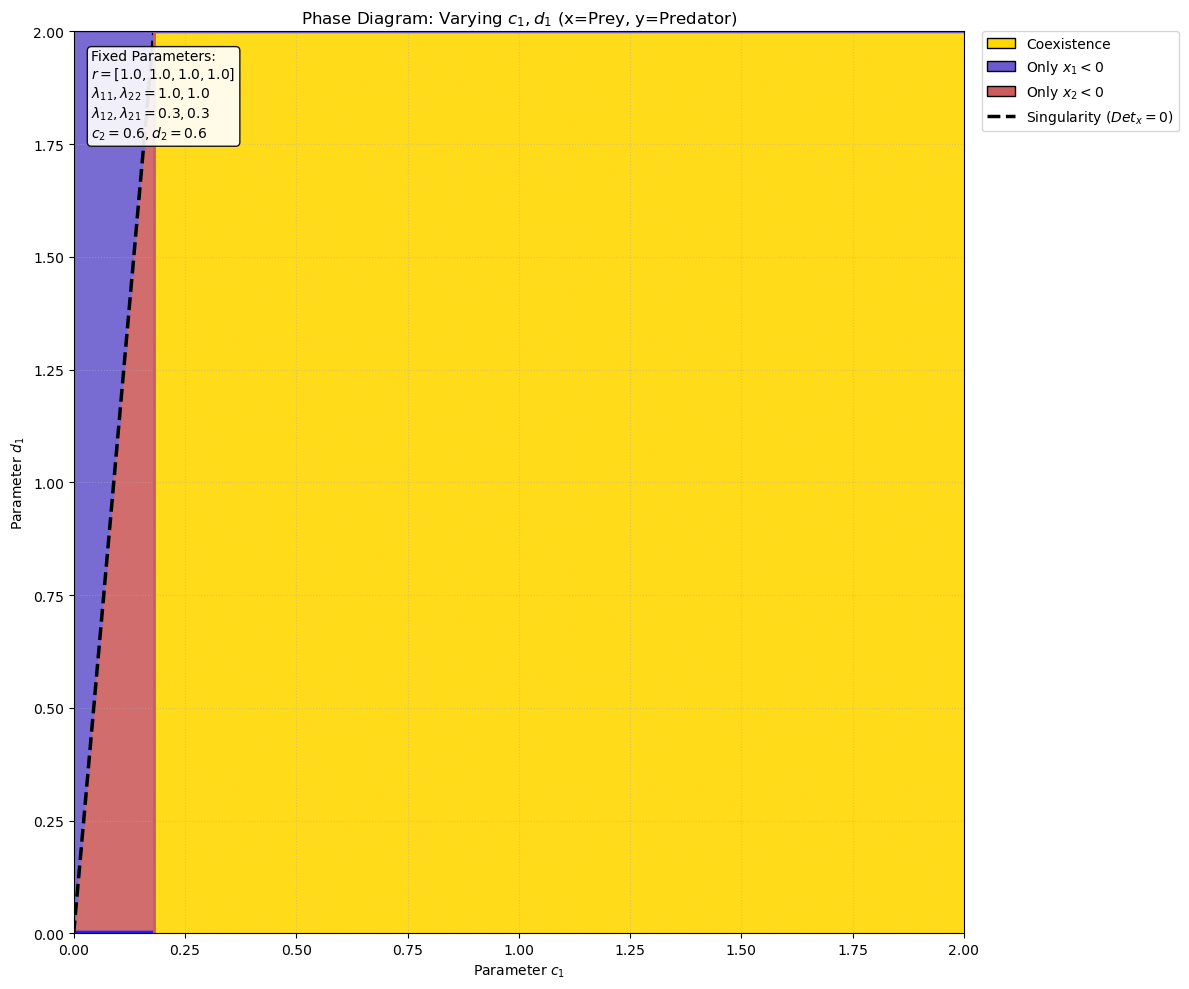

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. パラメータ設定
params = {
    'r': [1.0, 1.0, 1.0, 1.0],      # [rx1, ry1, rx2, ry2]
    'lambda_diag': [1.0, 1.0],      # [lambda11, lambda22] (固定)
    'lambda_offdiag': [0.3, 0.3],   # [lambda12, lambda21]
    'c2': 0.6,                      # c2 (固定)
    'd2': 0.6                       # d2 (固定)
}

rx1, ry1, rx2, ry2 = params['r']
l11, l22 = params['lambda_diag']
l12, l21 = params['lambda_offdiag']
c2 = params['c2']
d2 = params['d2']

# 2. メッシュグリッド (c1, d1 を変数とする)
res = 400
range_max = 2.0 
vals = np.linspace(0.001, range_max, res)
C1, D1 = np.meshgrid(vals, vals)

# 3. 計算 (x=被食者, y=捕食者 の構造へ変更)

# --- X (Prey: 被食者) の計算 ---
# 変数 C1, D1 はこちらに含まれます

# Det_x (旧 Det_y): c1 * d2 * l11 * l22 - c2 * d1 * l12 * l21
Det_x = C1 * d2 * l11 * l22 - c2 * D1 * l12 * l21

# Num_x1 (旧 Num_y1): d2 * l22 * rx1 - d1 * l21 * rx2
Num_x1 = d2 * l22 * rx1 - D1 * l21 * rx2

# Num_x2 (旧 Num_y2): c1 * l11 * rx2 - c2 * l12 * rx1
Num_x2 = C1 * l11 * rx2 - c2 * l12 * rx1


# --- Y (Predator: 捕食者) の計算 ---
# c, d を含まないため、このグリッド上では定数になります

# Det_y (旧 Det_x): l11 * l22 - l12 * l21
Det_y = l11 * l22 - l12 * l21

# Num_y1 (旧 Num_x1): l22 * ry1 - l12 * ry2
Num_y1 = l22 * ry1 - l12 * ry2

# Num_y2 (旧 Num_x2): l11 * ry2 - l21 * ry1
Num_y2 = l11 * ry2 - l21 * ry1


# 平衡点の値を計算
with np.errstate(divide='ignore', invalid='ignore'):
    X1 = Num_x1 / Det_x
    X2 = Num_x2 / Det_x
    # Yは定数ですが、グリッド計算のためにブロードキャストされます
    Y1 = Num_y1 / Det_y
    Y2 = Num_y2 / Det_y

# 4. 領域のカテゴリ分け (複合条件マスクの適用)
Category = np.zeros_like(X1, dtype=int)

# Y1, Y2 は定数なので、画面全体で同じ符号になります（パラメータ設定次第）
# X1, X2 は C1, D1 によって変化します
pos_x1 = X1 > 0
pos_x2 = X2 > 0
pos_y1 = Y1 > 0 # ここではスカラー的な判定になりますが配列として処理
pos_y2 = Y2 > 0

# --- Step 1: ベースとなる単独絶滅 (優先度: 低) ---
Category[~pos_y1] = 2  # y1 < 0 (SkyBlue)
Category[~pos_y2] = 3  # y2 < 0 (Salmon)
Category[~pos_x1] = 4  # x1 < 0 (SlateBlue)
Category[~pos_x2] = 5  # x2 < 0 (IndianRed)

# --- Step 2: 複合条件 (優先度: 高) ---
# 緑: y2 < 0 && x2 < 0
mask_green = (~pos_y2) & (~pos_x2)
Category[mask_green] = 6

# 灰色: y1 < 0 && x1 < 0
mask_gray = (~pos_y1) & (~pos_x1)
Category[mask_gray] = 7

# 赤色: y2 < 0 && x1 < 0
mask_red = (~pos_y2) & (~pos_x1)
Category[mask_red] = 8

# 青色: y1 < 0 && x2 < 0
mask_blue = (~pos_y1) & (~pos_x2)
Category[mask_blue] = 9

# --- Step 3: 共存 (最優先) ---
mask_coexist = pos_x1 & pos_x2 & pos_y1 & pos_y2
Category[mask_coexist] = 1

# 5. プロット
fig, ax = plt.subplots(figsize=(12, 10))

# カラーマップ定義 (0〜9)
colors = [
    'white',        # 0: None
    'gold',         # 1: Coexistence
    'skyblue',      # 2: y1 single extinction
    'salmon',       # 3: y2 single extinction
    'SlateBlue',    # 4: x1 single extinction
    'IndianRed',    # 5: x2 single extinction
    'MediumSeaGreen', # 6: y2<0 & x2<0 (Green)
    'lightgray',    # 7: y1<0 & x1<0 (Gray)
    'red',          # 8: y2<0 & x1<0 (Red)
    'blue'          # 9: y1<0 & x2<0 (Blue)
]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

im = ax.imshow(Category, extent=[0, range_max, 0, range_max], origin='lower',
               cmap=cmap, norm=norm, aspect='auto', alpha=0.9)

# --- 曲線描画 (計算式が入れ替わったため、線の意味も変わります) ---

# 1. Singularity (Det_x = 0)
# c1 * d2 * l11 * l22 = c2 * d1 * l12 * l21
# d1 = c1 * (d2 * l11 * l22) / (c2 * l12 * l21)
c1_line = np.linspace(0, range_max, 500)
slope = (d2 * l11 * l22) / (c2 * l12 * l21)
d1_line_det = c1_line * slope

ax.plot(c1_line, d1_line_det, color='black', linestyle='--', linewidth=2.5, 
        label=r'Singularity ($Det_x=0$)')

# 2. x1 = 0 Boundary (Num_x1 = 0)
# d2 * l22 * rx1 = d1 * l21 * rx2
# d1 = (d2 * l22 * rx1) / (l21 * rx2)  -> 水平線
d1_val_crit = (d2 * l22 * rx1) / (l21 * rx2)
ax.axhline(y=d1_val_crit, color='SlateBlue', linestyle='-', linewidth=2, 
           label=r'$x_1=0$ Boundary')

# 3. x2 = 0 Boundary (Num_x2 = 0)
# c1 * l11 * rx2 = c2 * l12 * rx1
# c1 = (c2 * l12 * rx1) / (l11 * rx2) -> 垂直線
c1_val_crit = (c2 * l12 * rx1) / (l11 * rx2)
ax.axvline(x=c1_val_crit, color='IndianRed', linestyle='-', linewidth=2, 
           label=r'$x_2=0$ Boundary')

# --- パラメータ表示 ---
textstr = '\n'.join(( 
    r'Fixed Parameters:',
    r'$r = [%.1f, %.1f, %.1f, %.1f]$' % tuple(params['r']),
    r'$\lambda_{11}, \lambda_{22} = %.1f, %.1f$' % (l11, l22),
    r'$\lambda_{12}, \lambda_{21} = %.1f, %.1f$' % (l12, l21),
    r'$c_2=%.1f, d_2=%.1f$' % (c2, d2)
))

props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# 軸ラベルとタイトル
ax.set_xlim(0, range_max)
ax.set_ylim(0, range_max)
ax.set_xlabel(r'Parameter $c_1$')
ax.set_ylabel(r'Parameter $d_1$')
ax.set_title(r'Phase Diagram: Varying $c_1, d_1$ (x=Prey, y=Predator)')
ax.grid(True, linestyle=':', alpha=0.5)

# --- 凡例 ---
legend_elements = [
    Patch(facecolor='gold', edgecolor='k', label='Coexistence'),
    
    
    # 単独・その他
    Patch(facecolor='SlateBlue', edgecolor='k', label='Only $x_1 < 0$'),
    Patch(facecolor='IndianRed', edgecolor='k', label='Only $x_2 < 0$'),
    
    Line2D([0], [0], color='black', lw=2.5, linestyle='--', label=r'Singularity ($Det_x=0$)'),
    
]

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

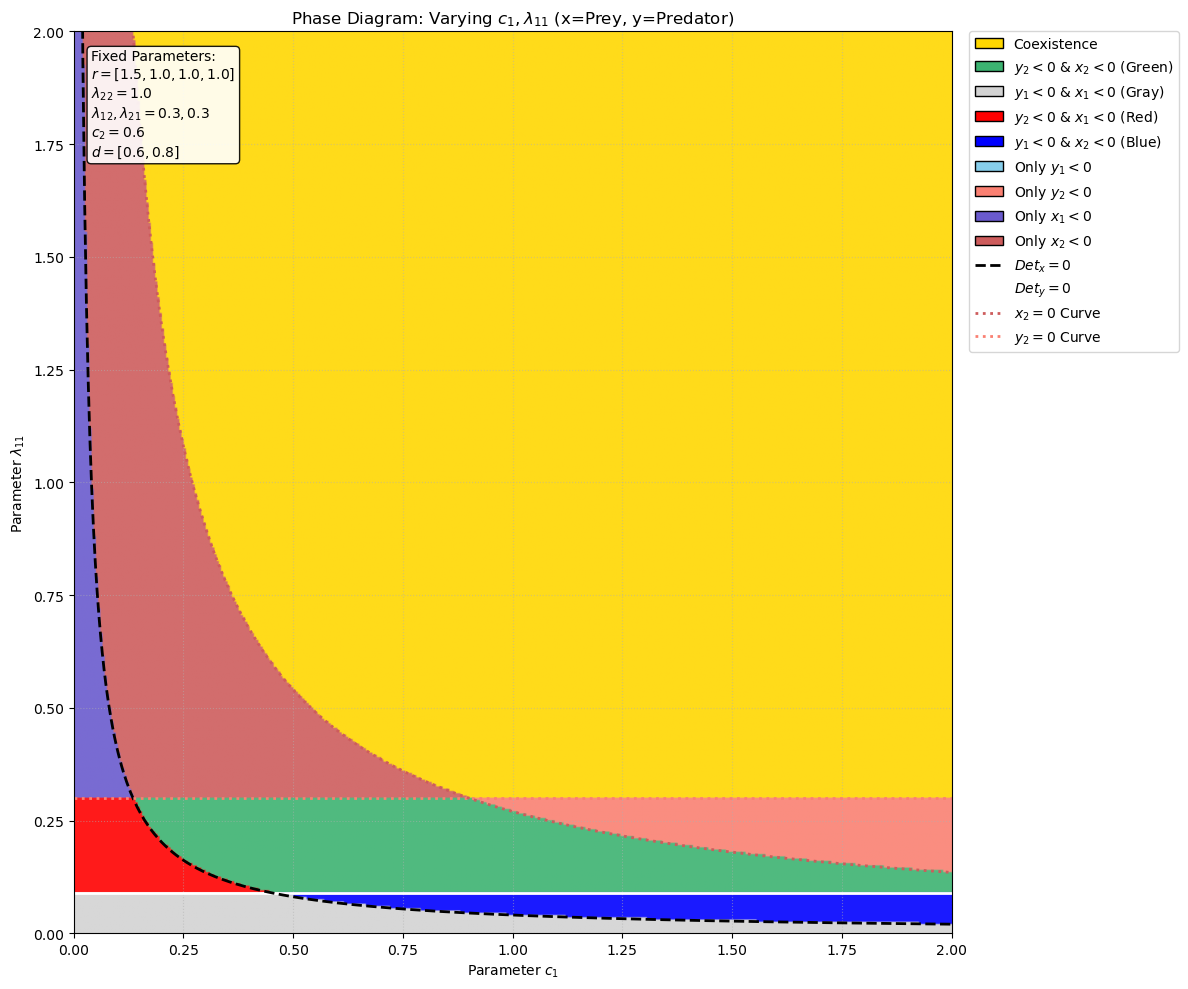

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. パラメータ設定
# c1, lambda11 を変数とし、他を固定します
params = {
    'r': [1.5, 1.0, 1.0, 1.0],      # [rx1, ry1, rx2, ry2]
    'lambda_fixed': 1.0,            # lambda22 (固定)
    'lambda_offdiag': [0.3, 0.3],   # [lambda12, lambda21]
    'c2': 0.6,                      # c2 (固定)
    'd': [0.6, 0.8]                 # [d1, d2]
}

rx1, ry1, rx2, ry2 = params['r']
l22 = params['lambda_fixed']        # l11 は変数
l12, l21 = params['lambda_offdiag']
c2 = params['c2']                   # c1 は変数
d1, d2 = params['d']

# 2. メッシュグリッド (c1, lambda11 を変数とする)
res = 400
range_c1 = 2.0   # x軸範囲
range_l11 = 2.0  # y軸範囲

c1_vals = np.linspace(0.001, range_c1, res)
l11_vals = np.linspace(0.001, range_l11, res)
C1, L11 = np.meshgrid(c1_vals, l11_vals)

# 3. 計算 (x=被食者, y=捕食者 の構造へ入れ替え)

# --- X (Prey: 被食者) の計算 ---
# 旧 Det_y -> 新 Det_x (変数 C1, L11 両方に依存)
# 式: c1 * d2 * l11 * l22 - c2 * d1 * l12 * l21
Det_x = C1 * d2 * L11 * l22 - c2 * d1 * l12 * l21

# 旧 Num_y1 -> 新 Num_x1 (すべて定数)
# 式: d2 * l22 * rx1 - d1 * l21 * rx2
Num_x1 = d2 * l22 * rx1 - d1 * l21 * rx2

# 旧 Num_y2 -> 新 Num_x2 (変数 C1, L11 両方に依存)
# 式: c1 * l11 * rx2 - c2 * l12 * rx1
Num_x2 = C1 * L11 * rx2 - c2 * l12 * rx1


# --- Y (Predator: 捕食者) の計算 ---
# 旧 Det_x -> 新 Det_y (変数 L11 に依存)
# 式: l11 * l22 - l12 * l21
Det_y = L11 * l22 - l12 * l21

# 旧 Num_x1 -> 新 Num_y1 (すべて定数)
# 式: l22 * ry1 - l12 * ry2
Num_y1 = l22 * ry1 - l12 * ry2

# 旧 Num_x2 -> 新 Num_y2 (変数 L11 に依存)
# 式: l11 * ry2 - l21 * ry1
Num_y2 = L11 * ry2 - l21 * ry1


# 平衡点の値を計算
with np.errstate(divide='ignore', invalid='ignore'):
    X1 = Num_x1 / Det_x
    X2 = Num_x2 / Det_x
    Y1 = Num_y1 / Det_y
    Y2 = Num_y2 / Det_y

# 4. 領域のカテゴリ分け (複合条件マスクの適用)
Category = np.zeros_like(X1, dtype=int)

pos_x1 = X1 > 0
pos_x2 = X2 > 0
pos_y1 = Y1 > 0
pos_y2 = Y2 > 0

# --- Step 1: ベースとなる単独絶滅 (優先度: 低) ---
Category[~pos_y1] = 2  # y1 < 0 (SkyBlue)
Category[~pos_y2] = 3  # y2 < 0 (Salmon)
Category[~pos_x1] = 4  # x1 < 0 (SlateBlue)
Category[~pos_x2] = 5  # x2 < 0 (IndianRed)

# --- Step 2: 複合条件 (優先度: 高) ---
# 緑: y2 < 0 && x2 < 0
mask_green = (~pos_y2) & (~pos_x2)
Category[mask_green] = 6

# 灰色: y1 < 0 && x1 < 0
mask_gray = (~pos_y1) & (~pos_x1)
Category[mask_gray] = 7

# 赤色: y2 < 0 && x1 < 0
mask_red = (~pos_y2) & (~pos_x1)
Category[mask_red] = 8

# 青色: y1 < 0 && x2 < 0
mask_blue = (~pos_y1) & (~pos_x2)
Category[mask_blue] = 9

# --- Step 3: 共存 (最優先) ---
mask_coexist = pos_x1 & pos_x2 & pos_y1 & pos_y2
Category[mask_coexist] = 1

# 5. プロット
fig, ax = plt.subplots(figsize=(12, 10))

# カラーマップ定義 (0〜9)
colors = [
    'white',        # 0: None
    'gold',         # 1: Coexistence
    'skyblue',      # 2: y1 single extinction
    'salmon',       # 3: y2 single extinction
    'SlateBlue',    # 4: x1 single extinction
    'IndianRed',    # 5: x2 single extinction
    'MediumSeaGreen', # 6: y2<0 & x2<0 (Green)
    'lightgray',    # 7: y1<0 & x1<0 (Gray)
    'red',          # 8: y2<0 & x1<0 (Red)
    'blue'          # 9: y1<0 & x2<0 (Blue)
]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

im = ax.imshow(Category, extent=[0, range_c1, 0, range_l11], origin='lower',
               cmap=cmap, norm=norm, aspect='auto', alpha=0.9)

# --- 曲線 (境界線) 描画 ---
# 計算式が入れ替わったため、境界線の意味も変わります
x_line = np.linspace(0.001, range_c1, 500)

# 1. Singularity Det_y = 0 (旧 Det_x)
# l11 * l22 = l12 * l21
# l11 = (l12 * l21) / l22 -> 水平線
l11_dety = (l12 * l21) / l22
ax.axhline(y=l11_dety, color='white', linestyle='-', linewidth=2, label=r'Singularity ($Det_y=0$)')

# 2. Singularity Det_x = 0 (旧 Det_y)
# c1 * d2 * l11 * l22 = c2 * d1 * l12 * l21
# l11 = (c2 * d1 * l12 * l21) / (d2 * l22 * c1) -> 双曲線 (y = k/x)
const_numerator = (c2 * d1 * l12 * l21)
const_denominator = (d2 * l22)
y_detx = const_numerator / (const_denominator * x_line)
ax.plot(x_line, y_detx, color='black', linestyle='--', linewidth=2, label=r'Singularity ($Det_x=0$)')

# 3. y2 = 0 Boundary (Num_y2 = 0)
# l11 * ry2 = l21 * ry1
# l11 = (l21 * ry1) / ry2 -> 水平線
l11_numy2 = (l21 * ry1) / ry2
ax.axhline(y=l11_numy2, color='salmon', linestyle=':', linewidth=2, label=r'$y_2=0$ Boundary')

# 4. x2 = 0 Boundary (Num_x2 = 0)
# c1 * l11 * rx2 = c2 * l12 * rx1
# l11 = (c2 * l12 * rx1) / (rx2 * c1) -> 双曲線
const_numx2 = (c2 * l12 * rx1) / rx2
y_numx2 = const_numx2 / x_line
ax.plot(x_line, y_numx2, color='IndianRed', linestyle=':', linewidth=2, label=r'$x_2=0$ Boundary')

# --- パラメータ表示 ---
textstr = '\n'.join(( 
    r'Fixed Parameters:',
    r'$r = [%.1f, %.1f, %.1f, %.1f]$' % tuple(params['r']),
    r'$\lambda_{22} = %.1f$' % l22,
    r'$\lambda_{12}, \lambda_{21} = %.1f, %.1f$' % (l12, l21),
    r'$c_2=%.1f$' % c2,
    r'$d = [%.1f, %.1f]$' % (d1, d2)
))

props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# 軸ラベルとタイトル
ax.set_xlim(0, range_c1)
ax.set_ylim(0, range_l11)
ax.set_xlabel(r'Parameter $c_1$')
ax.set_ylabel(r'Parameter $\lambda_{11}$')
ax.set_title(r'Phase Diagram: Varying $c_1, \lambda_{11}$ (x=Prey, y=Predator)')
ax.grid(True, linestyle=':', alpha=0.5)

# --- 凡例 ---
legend_elements = [
    Patch(facecolor='gold', edgecolor='k', label='Coexistence'),
    
    # 指定の組み合わせ
    Patch(facecolor='MediumSeaGreen', edgecolor='k', label='$y_2 < 0$ & $x_2 < 0$ (Green)'),
    Patch(facecolor='lightgray', edgecolor='k', label='$y_1 < 0$ & $x_1 < 0$ (Gray)'),
    Patch(facecolor='red', edgecolor='k', label='$y_2 < 0$ & $x_1 < 0$ (Red)'),
    Patch(facecolor='blue', edgecolor='k', label='$y_1 < 0$ & $x_2 < 0$ (Blue)'),
    
    # 単独・その他
    Patch(facecolor='skyblue', edgecolor='k', label='Only $y_1 < 0$'),
    Patch(facecolor='salmon', edgecolor='k', label='Only $y_2 < 0$'),
    Patch(facecolor='SlateBlue', edgecolor='k', label='Only $x_1 < 0$'),
    Patch(facecolor='IndianRed', edgecolor='k', label='Only $x_2 < 0$'),
    
    Line2D([0], [0], color='black', lw=2, linestyle='--', label=r'$Det_x=0$'),
    Line2D([0], [0], color='white', lw=2, label=r'$Det_y=0$'),
    Line2D([0], [0], color='IndianRed', lw=2, linestyle=':', label=r'$x_2=0$ Curve'),
    Line2D([0], [0], color='salmon', lw=2, linestyle=':', label=r'$y_2=0$ Curve'),
]

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.savefig("c_1vsl11.png")
plt.show()

/var/folders/y3/52y0s3c15rv2vx4qxr482p5m0000gn/T/ipykernel_2738/540198070.py:70: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  Category[~pos_y1] = 2
/var/folders/y3/52y0s3c15rv2vx4qxr482p5m0000gn/T/ipykernel_2738/540198070.py:71: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  Category[~pos_y2] = 3
/var/folders/y3/52y0s3c15rv2vx4qxr482p5m0000gn/T/ipykernel_2738/540198070.py:76: DeprecationWarning: Bitwise i

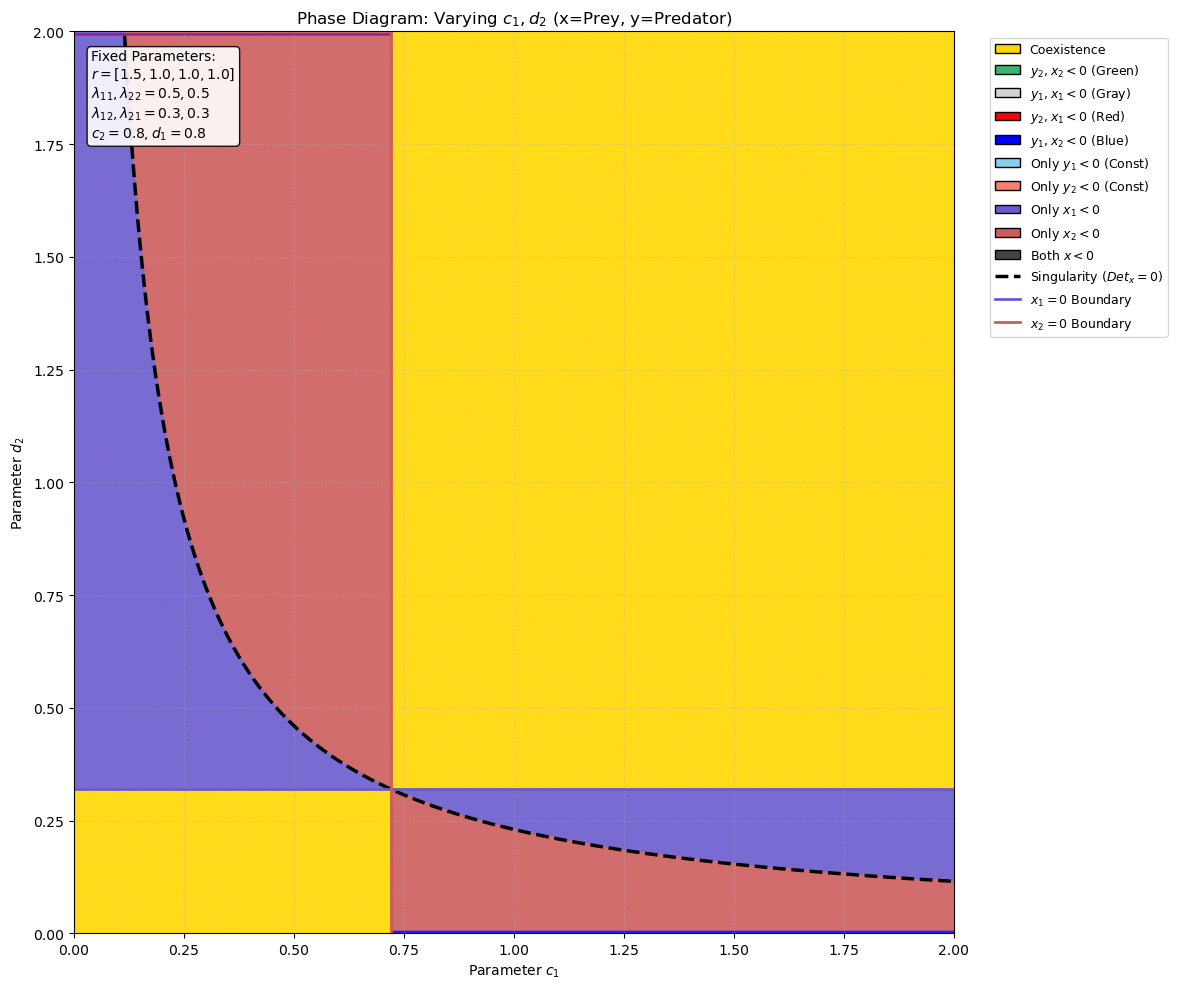

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. パラメータ設定
# c1, d2 を変数とし、他を固定
params = {
    'r': [1.5, 1.0, 1.0, 1.0],      # [rx1, ry1, rx2, ry2]
    'lambda_diag': [0.5, 0.5],      # [l11, l22] (固定)
    'lambda_offdiag': [0.3, 0.3],   # [l12, l21] (固定)
    'c_fixed': 0.8,                 # c2 (固定)
    'd_fixed': 0.8                  # d1 (固定)
}

rx1, ry1, rx2, ry2 = params['r']
l11, l22 = params['lambda_diag']
l12, l21 = params['lambda_offdiag']
c2 = params['c_fixed']
d1 = params['d_fixed']

# 2. メッシュグリッド (c1, d2 を変数とする)
res = 400
range_max = 2.0  # 範囲 0〜2.0

c1_vals = np.linspace(0.001, range_max, res)
d2_vals = np.linspace(0.001, range_max, res)
C1, D2 = np.meshgrid(c1_vals, d2_vals)

# 3. 平衡点の計算 (x=Prey, y=Predator)

# --- X (Prey: 被食者) ---
# Det_x: c1 * d2 * l11 * l22 - c2 * d1 * l12 * l21
# (C1, D2 が変数)
Det_x = C1 * D2 * l11 * l22 - c2 * d1 * l12 * l21

# Num_x1: d2 * l22 * rx1 - d1 * l21 * rx2
# (D2 が変数)
Num_x1 = D2 * l22 * rx1 - d1 * l21 * rx2

# Num_x2: c1 * l11 * rx2 - c2 * l12 * rx1
# (C1 が変数)
Num_x2 = C1 * l11 * rx2 - c2 * l12 * rx1


# --- Y (Predator: 捕食者) ---
# c, d に依存しないため、このグリッド上では定数となります
Det_y = l11 * l22 - l12 * l21
Num_y1 = l22 * ry1 - l12 * ry2
Num_y2 = l11 * ry2 - l21 * ry1

with np.errstate(divide='ignore', invalid='ignore'):
    X1 = Num_x1 / Det_x
    X2 = Num_x2 / Det_x
    # Yはスカラーですがグリッド演算のためにブロードキャスト
    Y1 = Num_y1 / Det_y
    Y2 = Num_y2 / Det_y

# 4. 領域のカテゴリ分け
Category = np.zeros_like(X1, dtype=int)

pos_x1 = X1 > 0
pos_x2 = X2 > 0
# Y1, Y2は全画面で符号が同じ（このパラメータ設定では正）
pos_y1 = Y1 > 0 
pos_y2 = Y2 > 0

# Base Layer (単独死滅)
Category[~pos_y1] = 2
Category[~pos_y2] = 3
Category[~pos_x1] = 4
Category[~pos_x2] = 5

# Middle Layer (両方死滅)
mask_both_y = (~pos_y1) & (~pos_y2)
Category[mask_both_y] = 10
mask_both_x = (~pos_x1) & (~pos_x2)
Category[mask_both_x] = 11

# Top Layer (複合条件)
mask_green = (~pos_y2) & (~pos_x2)
Category[mask_green] = 6
mask_gray = (~pos_y1) & (~pos_x1)
Category[mask_gray] = 7
mask_red = (~pos_y2) & (~pos_x1)
Category[mask_red] = 8
mask_blue = (~pos_y1) & (~pos_x2)
Category[mask_blue] = 9

# Coexistence
mask_coexist = pos_x1 & pos_x2 & pos_y1 & pos_y2
Category[mask_coexist] = 1

# 5. プロット
fig, ax = plt.subplots(figsize=(12, 10))

colors = [
    'white', 'gold', 
    'skyblue', 'salmon', 'SlateBlue', 'IndianRed', 
    'MediumSeaGreen', 'lightgray', 'red', 'blue', 
    'purple', '#444444'
]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 12.5, 1), cmap.N)

im = ax.imshow(Category, extent=[0, range_max, 0, range_max], origin='lower',
               cmap=cmap, norm=norm, aspect='auto', alpha=0.9)

# --- 曲線 (境界線) 描画 ---
x_line = np.linspace(0.001, range_max, 500)

# 1. Singularity Det_x = 0 (黒色破線)
# c1 * d2 * l11 * l22 = c2 * d1 * l12 * l21
# d2 = (c2 * d1 * l12 * l21) / (l11 * l22 * c1)  -> 双曲線
numerator_k = c2 * d1 * l12 * l21
denominator_k = l11 * l22
y_detx = numerator_k / (denominator_k * x_line)
ax.plot(x_line, y_detx, color='black', linestyle='--', linewidth=2.5, label=r'Singularity ($Det_x=0$)')

# 2. x1 = 0 Boundary (Num_x1 = 0) -> d2 についての水平線
# d2 * l22 * rx1 = d1 * l21 * rx2
# d2 = (d1 * l21 * rx2) / (l22 * rx1)
d2_crit = (d1 * l21 * rx2) / (l22 * rx1)
ax.axhline(y=d2_crit, color='SlateBlue', linestyle='-', linewidth=2, label=r'$x_1=0$ Boundary')

# 3. x2 = 0 Boundary (Num_x2 = 0) -> c1 についての垂直線
# c1 * l11 * rx2 = c2 * l12 * rx1
# c1 = (c2 * l12 * rx1) / (l11 * rx2)
c1_crit = (c2 * l12 * rx1) / (l11 * rx2)
ax.axvline(x=c1_crit, color='IndianRed', linestyle='-', linewidth=2, label=r'$x_2=0$ Boundary')

# ※ Det_y, Num_y は c, d に依存しないため、境界線はこの平面上には存在しません（または無限遠）

# --- パラメータ表示 ---
textstr = '\n'.join((
    r'Fixed Parameters:',
    r'$r = [%.1f, %.1f, %.1f, %.1f]$' % tuple(params['r']),
    r'$\lambda_{11}, \lambda_{22} = %.1f, %.1f$' % (l11, l22),
    r'$\lambda_{12}, \lambda_{21} = %.1f, %.1f$' % (l12, l21),
    r'$c_2=%.1f, d_1=%.1f$' % (c2, d1)
))

props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# 凡例
legend_elements = [
    Patch(facecolor='gold', edgecolor='k', label='Coexistence'),
    
    # 複合条件 (Yが正のため、この図では出現しない可能性がありますが一貫性のため残します)
    Patch(facecolor='MediumSeaGreen', edgecolor='k', label='$y_2, x_2 < 0$ (Green)'),
    Patch(facecolor='lightgray', edgecolor='k', label='$y_1, x_1 < 0$ (Gray)'),
    Patch(facecolor='red', edgecolor='k', label='$y_2, x_1 < 0$ (Red)'),
    Patch(facecolor='blue', edgecolor='k', label='$y_1, x_2 < 0$ (Blue)'),
    
    # 単独・その他
    Patch(facecolor='skyblue', edgecolor='k', label='Only $y_1 < 0$ (Const)'),
    Patch(facecolor='salmon', edgecolor='k', label='Only $y_2 < 0$ (Const)'),
    Patch(facecolor='SlateBlue', edgecolor='k', label='Only $x_1 < 0$'),
    Patch(facecolor='IndianRed', edgecolor='k', label='Only $x_2 < 0$'),
    Patch(facecolor='#444444', edgecolor='k', label='Both $x < 0$'),

    Line2D([0], [0], color='black', lw=2.5, linestyle='--', label=r'Singularity ($Det_x=0$)'),
    Line2D([0], [0], color='SlateBlue', lw=2, linestyle='-', label=r'$x_1=0$ Boundary'),
    Line2D([0], [0], color='IndianRed', lw=2, linestyle='-', label=r'$x_2=0$ Boundary')
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=9, bbox_to_anchor=(1.25, 1))
ax.set_xlabel(r'Parameter $c_1$')
ax.set_ylabel(r'Parameter $d_2$')
ax.set_title(r'Phase Diagram: Varying $c_1, d_2$ (x=Prey, y=Predator)')
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlim(0, range_max)
ax.set_ylim(0, range_max)

plt.tight_layout()
plt.savefig("c_1vsd_2")
plt.show()